# Sprint 2: Miami-Dade Tract-Level ACS Census EDA
## AI for Equitable Public Transportation — Deloitte Capstone

**Objective:** Conduct granular exploratory data analysis on Miami-Dade tract-level ACS data (707 tracts, 49 variables) to identify demographic, economic, housing, and transit equity patterns.

**Key Upgrade from Sprint 1:** State-level data (146 rows) → Tract-level data (707 tracts) = 5x granularity improvement.

**Data Source:** American Community Survey (ACS) 5-year estimates
**Geographic Unit:** Census tracts (Miami-Dade County)
**Key Domains:** Demographics (DP05), Economics (DP03), Housing (DP04), Transit Equity

In [13]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
deloitte_colors = {
    'dark_green': '#005030',
    'light_green': '#9bbb59',
    'orange': '#f47321',
    'light_orange': '#f79646',
    'gray': '#888888'
}
color_palette = [deloitte_colors['dark_green'], deloitte_colors['light_green'], 
                  deloitte_colors['orange'], deloitte_colors['light_orange']]
sns.set_palette(color_palette)

print("Environment configured. Ready to load data.")

Environment configured. Ready to load data.


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('../ACS Tract Level Data/Census_MiamiDade_Tracts_Combined.csv')

print(f"Initial shape: {df.shape}")
print(f"\nColumn names ({len(df.columns)} total):")
print(df.columns.tolist())

Initial shape: (707, 49)

Column names (49 total):
['GEOID', 'NAME', 'employment_rate_pct', 'unemployment_rate_pct', 'commute_drove_alone_pct', 'commute_public_transit_pct', 'commute_walked_pct', 'commute_wfh_pct', 'mean_commute_time_min', 'median_household_income', 'mean_household_income', 'per_capita_income', 'hh_income_under_10k_pct', 'hh_income_10k_15k_pct', 'hh_income_15k_25k_pct', 'hh_income_25k_35k_pct', 'hh_income_35k_50k_pct', 'hh_income_50k_75k_pct', 'hh_income_75k_100k_pct', 'hh_income_100k_150k_pct', 'hh_income_150k_200k_pct', 'hh_income_200k_plus_pct', 'poverty_rate_pct', 'snap_benefits_pct', 'no_health_insurance_pct', 'hh_no_vehicle_pct', 'hh_1_vehicle_pct', 'hh_2_vehicles_pct', 'hh_3plus_vehicles_pct', 'owner_occupied_pct', 'renter_occupied_pct', 'median_gross_rent', 'rent_burden_30pct_plus', 'rent_burden_50pct_plus', 'total_housing_units', 'occupied_units_pct', 'vacant_units_pct', 'total_population', 'median_age', 'under_18_pct', 'age_65_plus_pct', 'hispanic_latino_pct'

In [3]:
sentinel_val = -666666666
sentinel_mask = (df == sentinel_val).any(axis=1)
print(f"Tracts with sentinel values: {sentinel_mask.sum()}")
print(f"Percentage: {100 * sentinel_mask.sum() / len(df):.1f}%")

Tracts with sentinel values: 53
Percentage: 7.5%


In [4]:
df_clean = df.replace(sentinel_val, np.nan).copy()

print(f"Sentinel values after replacement: {(df_clean == sentinel_val).sum().sum()}")
print(f"\nDataframe shape: {df_clean.shape}")
print(df_clean.head())

Sentinel values after replacement: 0

Dataframe shape: (707, 49)
         GEOID                                           NAME  \
0  12086000107  Census Tract 1.07; Miami-Dade County; Florida   
1  12086000109  Census Tract 1.09; Miami-Dade County; Florida   
2  12086000115  Census Tract 1.15; Miami-Dade County; Florida   
3  12086000118  Census Tract 1.18; Miami-Dade County; Florida   
4  12086000120  Census Tract 1.20; Miami-Dade County; Florida   

   employment_rate_pct  unemployment_rate_pct  commute_drove_alone_pct  \
0                 60.1                    3.8                     61.6   
1                 65.5                    1.3                     65.3   
2                 52.8                    8.7                     63.9   
3                 43.3                    4.6                     47.3   
4                 57.3                    8.5                     59.8   

   commute_public_transit_pct  commute_walked_pct  commute_wfh_pct  \
0                         3.3

## 2. Data Quality & Missingness Assessment

In [6]:
missing_summary = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Pct': 100 * df_clean.isnull().sum() / len(df_clean)
}).sort_values('Missing_Pct', ascending=False)

print("Columns with missing data:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

missing_per_tract = df_clean.isnull().sum(axis=1)
empty_tracts = df_clean[missing_per_tract > 40]
print(f"\nTracts with severe data gaps (>40 missing columns): {len(empty_tracts)}")
if len(empty_tracts) > 0:
    print(f"\n{'GEOID':<15} {'NAME':<45} {'Missing Cols':>12} {'Population':>12}")
    print("-" * 86)
    for _, row in empty_tracts.iterrows():
        pop = row['total_population'] if pd.notna(row['total_population']) else 'N/A'
        n_missing = int(missing_per_tract.loc[row.name])
        print(f"{str(row['GEOID']):<15} {str(row['NAME'])[:44]:<45} {n_missing:>12} {str(pop):>12}")

Columns with missing data:
                                                Column  Missing_Count  \
median_gross_rent                    median_gross_rent             49   
median_household_income        median_household_income             16   
rent_burden_30pct_plus          rent_burden_30pct_plus             12   
rent_burden_50pct_plus          rent_burden_50pct_plus             12   
no_health_insurance_pct        no_health_insurance_pct              9   
median_age                                  median_age              9   
hh_2_vehicles_pct                    hh_2_vehicles_pct              9   
hh_3plus_vehicles_pct            hh_3plus_vehicles_pct              9   
owner_occupied_pct                  owner_occupied_pct              9   
renter_occupied_pct                renter_occupied_pct              9   
occupied_units_pct                  occupied_units_pct              9   
vacant_units_pct                      vacant_units_pct              9   
under_18_pct            

## 3. Demographic Overview (DP05)

In [7]:
demo_stats = df_clean[[
    'total_population', 'median_age', 'hispanic_latino_pct', 
    'black_alone_nh_pct', 'white_alone_nh_pct', 'foreign_born_pct'
]].describe()

print("=== DEMOGRAPHIC PROFILE ===")
print(demo_stats.round(2))

print(f"\nMiami-Dade is {df_clean['hispanic_latino_pct'].mean():.1f}% Hispanic (median)")
print(f"Range: {df_clean['hispanic_latino_pct'].min():.1f}% to {df_clean['hispanic_latino_pct'].max():.1f}%")

=== DEMOGRAPHIC PROFILE ===
       total_population  median_age  hispanic_latino_pct  black_alone_nh_pct  \
count            707.00      698.00               698.00              698.00   
mean            3798.16       41.92                68.51               13.64   
std             1507.90        6.62                23.84               21.78   
min                0.00       19.30                 2.50                0.00   
25%             2789.50       37.60                51.22                0.32   
50%             3774.00       41.40                73.80                2.80   
75%             4661.50       46.80                89.68               15.35   
max            12936.00       75.60               100.00               96.40   

       white_alone_nh_pct  foreign_born_pct  
count              698.00            698.00  
mean                13.99              0.52  
std                 14.76              1.13  
min                  0.00              0.00  
25%                  

Tract Types by Racial/Ethnic Composition (out of 707 tracts):
majority_group
Majority Hispanic    459
Mixed                142
Majority Black        80
Majority White        26
Name: count, dtype: int64


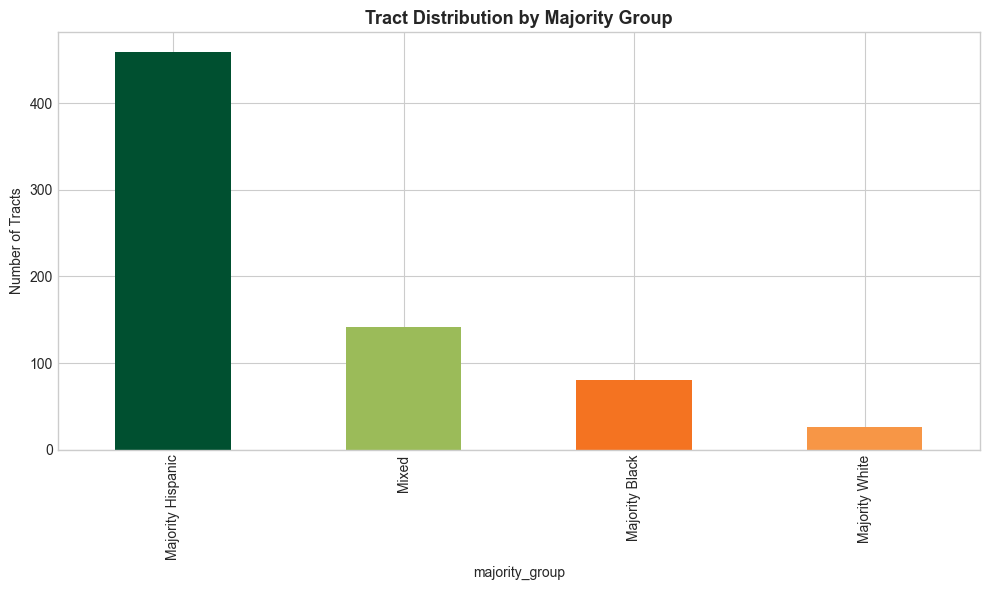

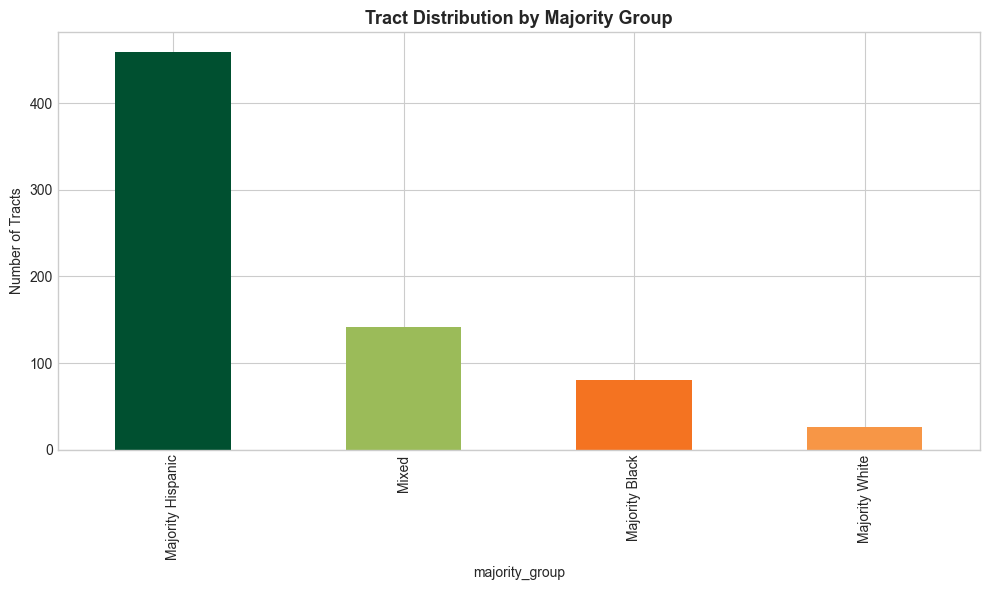

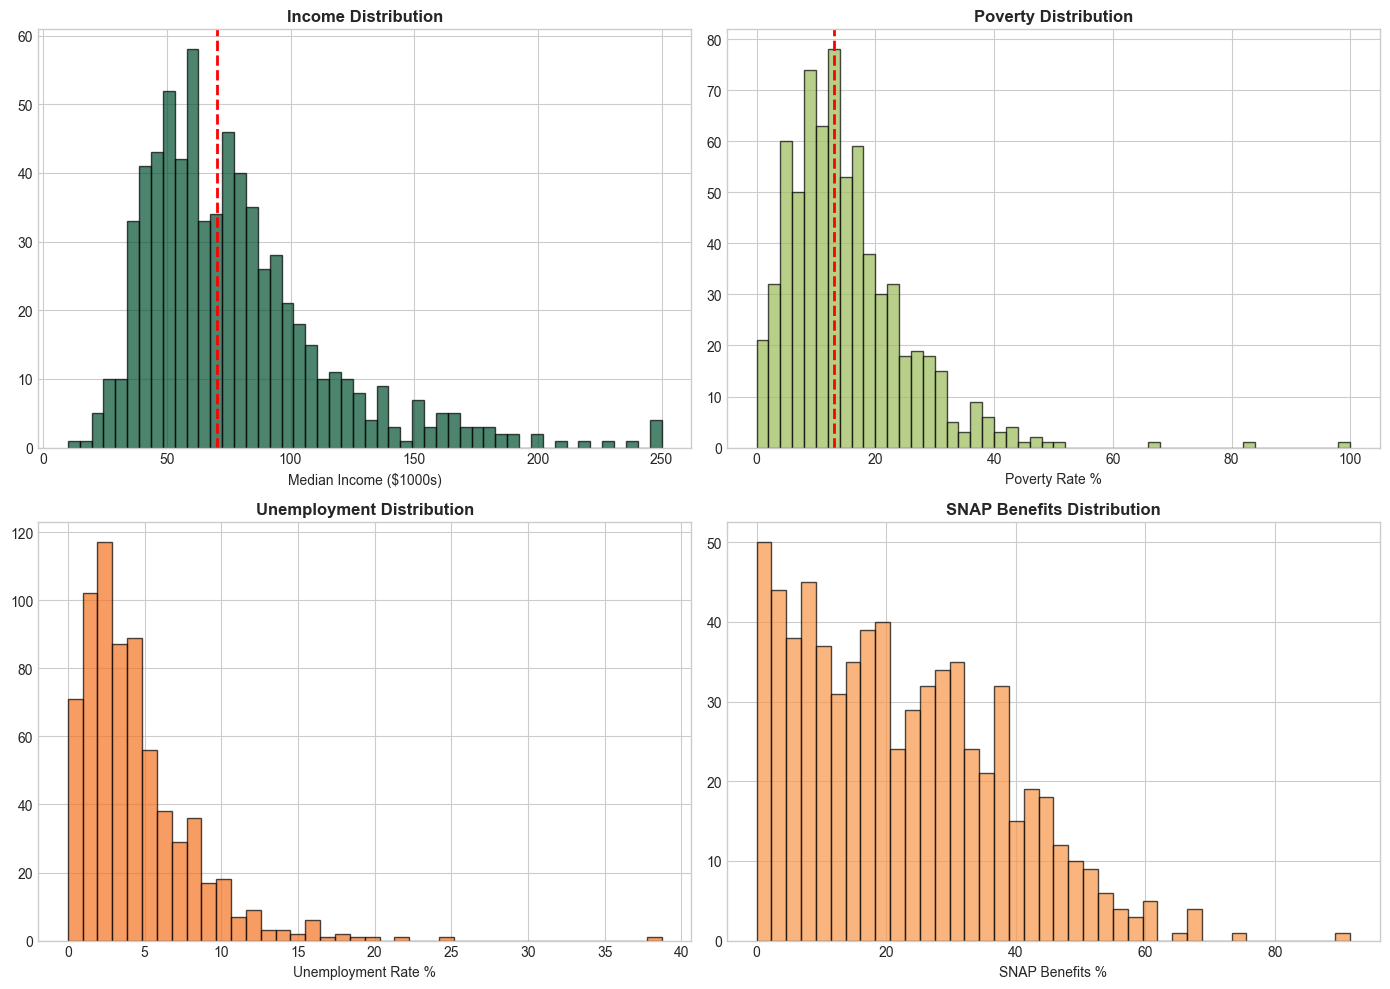

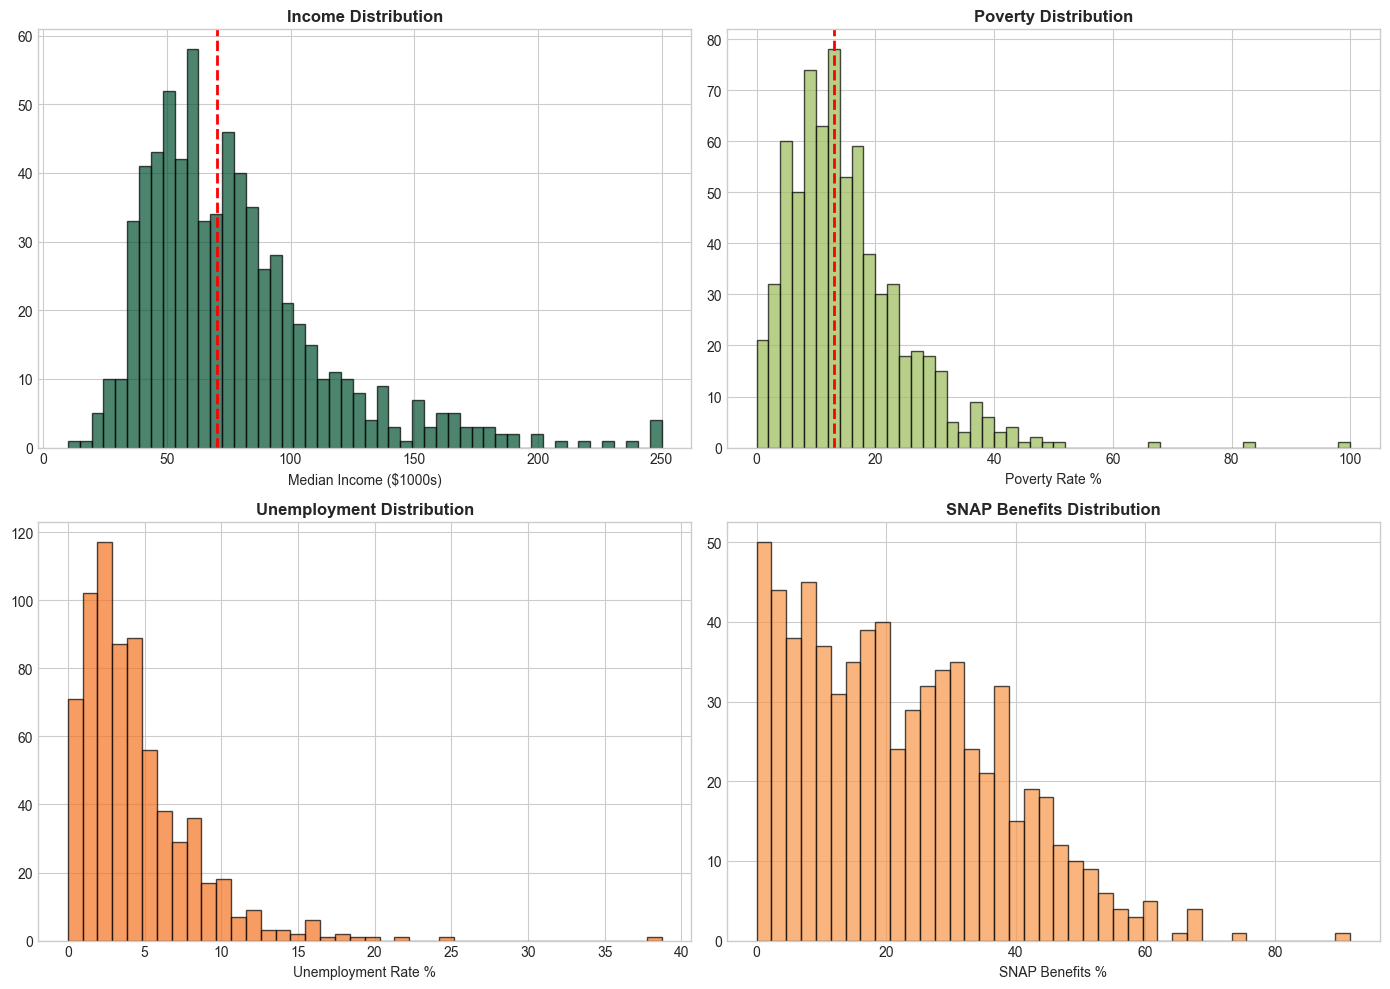

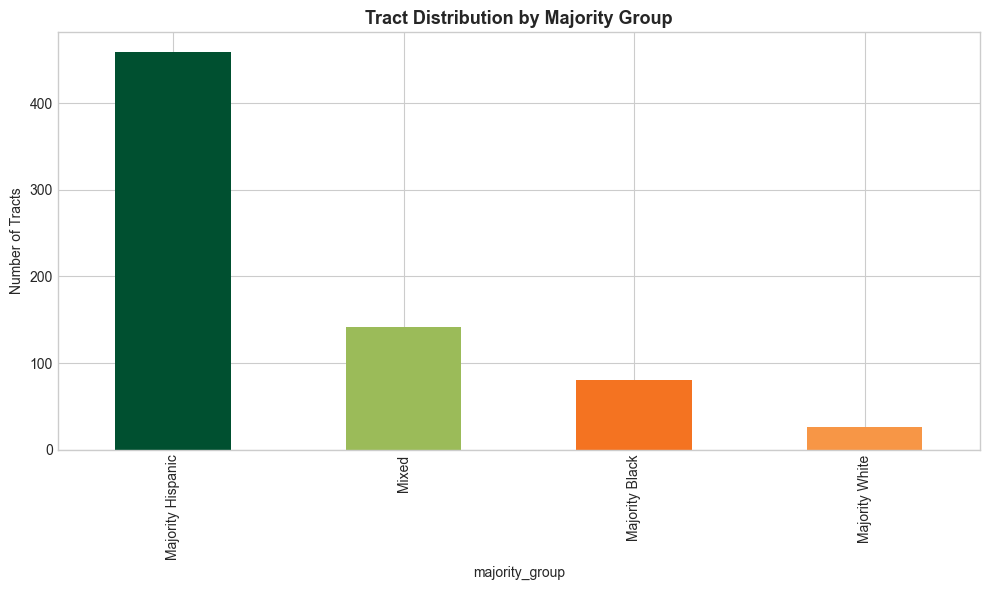

In [14]:
df_clean['majority_group'] = 'Mixed'
df_clean.loc[df_clean['hispanic_latino_pct'] > 60, 'majority_group'] = 'Majority Hispanic'
df_clean.loc[df_clean['black_alone_nh_pct'] > 50, 'majority_group'] = 'Majority Black'
df_clean.loc[df_clean['white_alone_nh_pct'] > 50, 'majority_group'] = 'Majority White'

print("Tract Types by Racial/Ethnic Composition (out of 707 tracts):")
print(df_clean['majority_group'].value_counts())

fig, ax = plt.subplots(figsize=(10, 6))
df_clean['majority_group'].value_counts().plot(kind='bar', ax=ax, color=color_palette)
ax.set_title('Tract Distribution by Majority Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Tracts')
plt.tight_layout()
plt.savefig('tract_majority_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Economic Profile (DP03): Income & Poverty

In [10]:
econ_stats = df_clean[[
    'median_household_income', 'poverty_rate_pct', 'unemployment_rate_pct',
    'snap_benefits_pct'
]].describe()

print("=== ECONOMIC PROFILE ===")
print(econ_stats.round(2))

print(f"\nMedian Household Income: ${df_clean['median_household_income'].median():,.0f}")
print(f"Range: ${df_clean['median_household_income'].min():,.0f} to ${df_clean['median_household_income'].max():,.0f}")
print(f"Income ratio (max/min): {df_clean['median_household_income'].max() / df_clean['median_household_income'].min():.1f}x")
print(f"\nMedian Poverty Rate: {df_clean['poverty_rate_pct'].median():.1f}%")

=== ECONOMIC PROFILE ===
       median_household_income  poverty_rate_pct  unemployment_rate_pct  \
count                   691.00            698.00                 698.00   
mean                  77444.81             15.13                   4.42   
std                   37827.68             10.22                   3.75   
min                    9960.00              0.00                   0.00   
25%                   51223.00              8.20                   2.00   
50%                   70118.00             13.10                   3.50   
75%                   93147.50             19.70                   5.90   
max                  250001.00            100.00                  38.70   

       snap_benefits_pct  
count             698.00  
mean               22.39  
std                15.70  
min                 0.00  
25%                 8.90  
50%                20.05  
75%                32.78  
max                91.60  

Median Household Income: $70,118
Range: $9,960 to $250,

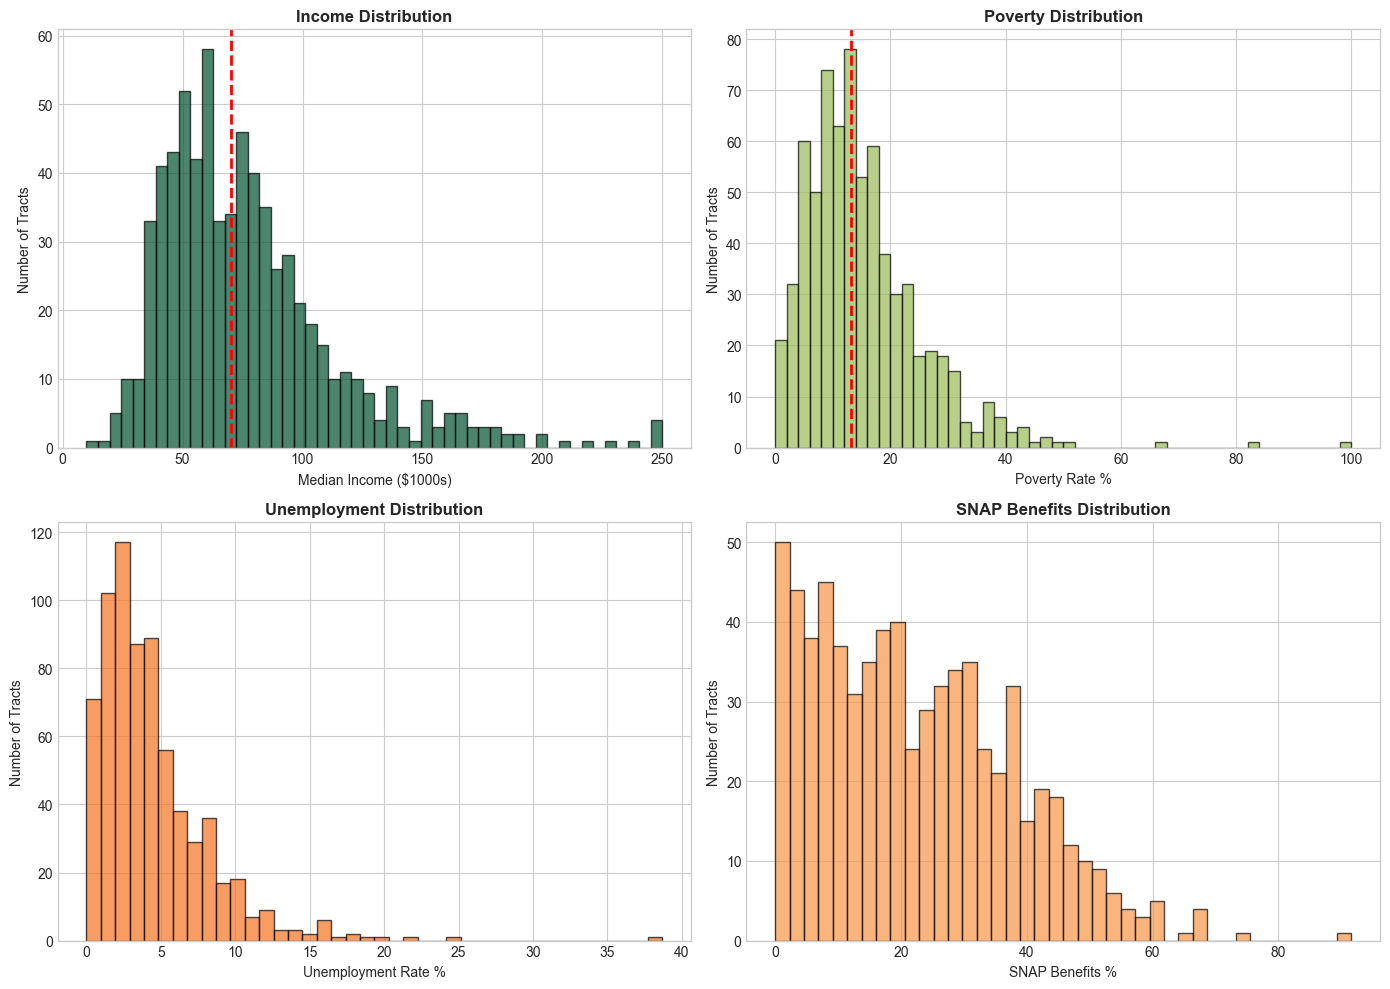

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(df_clean['median_household_income'].dropna()/1000, bins=50, 
        color=deloitte_colors['dark_green'], alpha=0.7, edgecolor='black')
ax.axvline(df_clean['median_household_income'].median()/1000, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Median Income ($1000s)')
ax.set_ylabel('Number of Tracts')
ax.set_title('Income Distribution', fontweight='bold')

ax = axes[0, 1]
ax.hist(df_clean['poverty_rate_pct'].dropna(), bins=50, 
        color=deloitte_colors['light_green'], alpha=0.7, edgecolor='black')
ax.axvline(df_clean['poverty_rate_pct'].median(), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Poverty Rate %')
ax.set_ylabel('Number of Tracts')
ax.set_title('Poverty Distribution', fontweight='bold')

ax = axes[1, 0]
ax.hist(df_clean['unemployment_rate_pct'].dropna(), bins=40,
        color=deloitte_colors['orange'], alpha=0.7, edgecolor='black')
ax.set_xlabel('Unemployment Rate %')
ax.set_ylabel('Number of Tracts')
ax.set_title('Unemployment Distribution', fontweight='bold')

ax = axes[1, 1]
ax.hist(df_clean['snap_benefits_pct'].dropna(), bins=40,
        color=deloitte_colors['light_orange'], alpha=0.7, edgecolor='black')
ax.set_xlabel('SNAP Benefits %')
ax.set_ylabel('Number of Tracts')
ax.set_title('SNAP Benefits Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('economic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Housing & Vehicle Access (DP04)

In [17]:
housing_stats = df_clean[[
    'hh_no_vehicle_pct', 'hh_1_vehicle_pct', 'hh_2_vehicles_pct', 'hh_3plus_vehicles_pct',
    'median_gross_rent', 'rent_burden_30pct_plus'
]].describe()

print("=== HOUSING & VEHICLE ACCESS ===")
print(housing_stats.round(2))

print(f"\nNo-Vehicle Households (median): {df_clean['hh_no_vehicle_pct'].median():.1f}%")
print(f"Range: {df_clean['hh_no_vehicle_pct'].min():.1f}% to {df_clean['hh_no_vehicle_pct'].max():.1f}%")
print(f"\nMedian Gross Rent: ${df_clean['median_gross_rent'].median():.0f}")

=== HOUSING & VEHICLE ACCESS ===
       hh_no_vehicle_pct  hh_1_vehicle_pct  hh_2_vehicles_pct  \
count             698.00            698.00             698.00   
mean                9.49             37.29              35.09   
std                10.15             15.27              12.52   
min                 0.00              0.00               0.00   
25%                 2.70             26.50              27.52   
50%                 6.30             36.15              35.20   
75%                12.48             48.05              44.10   
max               100.00            100.00              73.10   

       hh_3plus_vehicles_pct  median_gross_rent  rent_burden_30pct_plus  
count                 698.00             658.00                  695.00  
mean                   18.13            1926.09                    8.98  
std                    12.49             574.91                    9.33  
min                     0.00             286.00                    0.00  
25%        

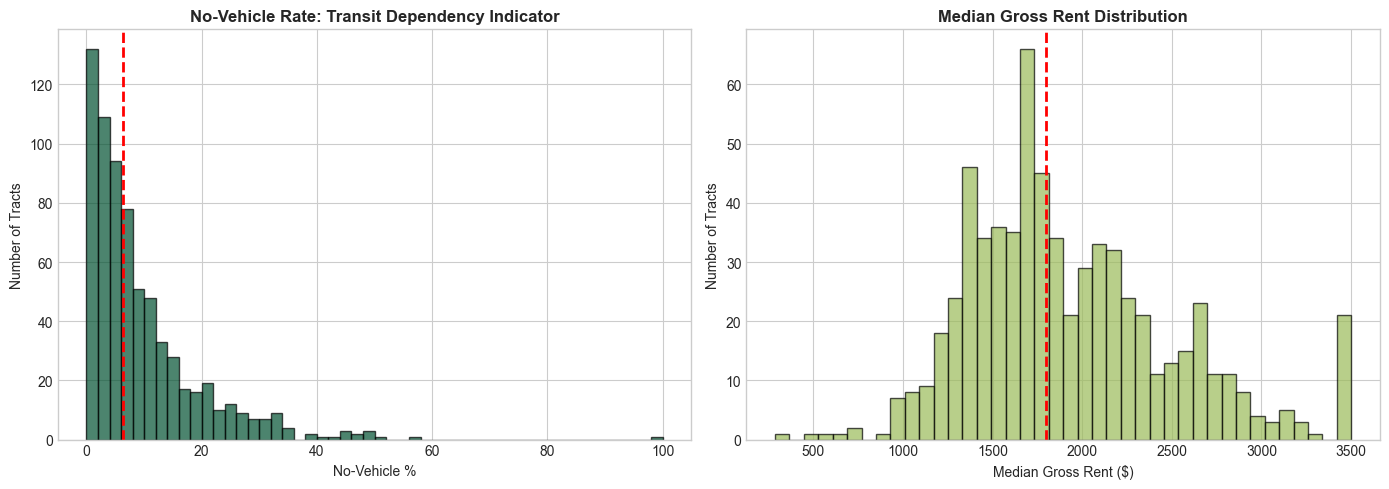

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df_clean['hh_no_vehicle_pct'].dropna(), bins=50,
        color=deloitte_colors['dark_green'], alpha=0.7, edgecolor='black')
ax.axvline(df_clean['hh_no_vehicle_pct'].median(), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('No-Vehicle %')
ax.set_ylabel('Number of Tracts')
ax.set_title('No-Vehicle Rate: Transit Dependency Indicator', fontweight='bold')

ax = axes[1]
ax.hist(df_clean['median_gross_rent'].dropna(), bins=40,
        color=deloitte_colors['light_green'], alpha=0.7, edgecolor='black')
ax.axvline(df_clean['median_gross_rent'].median(), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Median Gross Rent ($)')
ax.set_ylabel('Number of Tracts')
ax.set_title('Median Gross Rent Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('housing_vehicle_access.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Transit Equity Deep Dive: Core Question

In [20]:
transit_stats = df_clean[[
    'commute_drove_alone_pct', 'commute_public_transit_pct', 'commute_walked_pct',
    'mean_commute_time_min'
]].describe()

print("=== COMMUTE MODE DISTRIBUTION ===")
print(transit_stats.round(2))

print(f"\n*** CRITICAL INSIGHT ***")
print(f"Public Transit Usage (median): {df_clean['commute_public_transit_pct'].median():.1f}%")
print(f"No-Vehicle Rate (median): {df_clean['hh_no_vehicle_pct'].median():.1f}%")
print(f"\nGAP: {df_clean['hh_no_vehicle_pct'].median() - df_clean['commute_public_transit_pct'].median():.1f} percentage points")
print(f"\nThis gap reveals: Current transit network fails to serve transit-dependent populations")

=== COMMUTE MODE DISTRIBUTION ===
       commute_drove_alone_pct  commute_public_transit_pct  \
count                   698.00                      698.00   
mean                     70.00                        3.42   
std                      12.78                        4.93   
min                      14.30                        0.00   
25%                      63.50                        0.30   
50%                      72.80                        1.80   
75%                      79.10                        4.40   
max                      94.60                       45.70   

       commute_walked_pct  mean_commute_time_min  
count              698.00           6.980000e+02  
mean                 2.25          -2.865299e+06  
std                  4.69           5.349036e+07  
min                  0.00          -1.000000e+09  
25%                  0.00           2.630000e+01  
50%                  0.60           3.005000e+01  
75%                  2.70           3.398000e+01  


Transit Usage by Income Quintile:
income_quintile
Q1 (Lowest)     6.99
Q2              3.78
Q3              2.46
Q4              2.06
Q5 (Highest)    1.87
Name: commute_public_transit_pct, dtype: float64


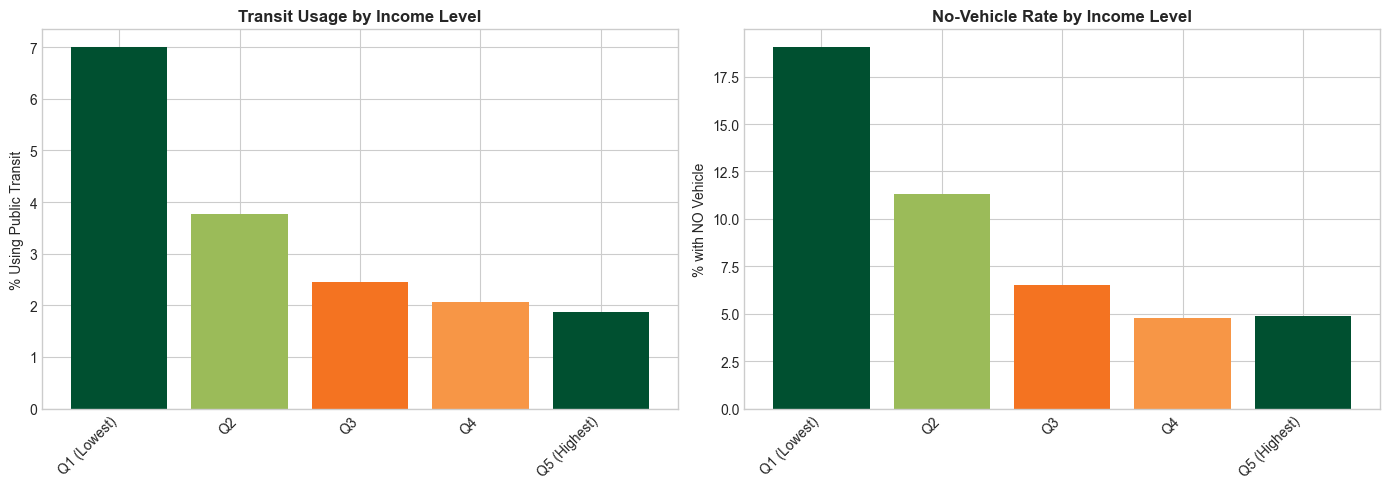

In [21]:
df_clean['income_quintile'] = pd.qcut(
    df_clean['median_household_income'].dropna(), q=5,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'],
    duplicates='drop'
)

print("\nTransit Usage by Income Quintile:")
print(df_clean.groupby('income_quintile', observed=True)['commute_public_transit_pct'].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
transit_by_income = df_clean.groupby('income_quintile', observed=True)['commute_public_transit_pct'].mean()
ax.bar(range(len(transit_by_income)), transit_by_income.values, color=color_palette[:len(transit_by_income)])
ax.set_xticks(range(len(transit_by_income)))
ax.set_xticklabels(transit_by_income.index, rotation=45, ha='right')
ax.set_ylabel('% Using Public Transit')
ax.set_title('Transit Usage by Income Level', fontweight='bold')

ax = axes[1]
novehicle_by_income = df_clean.groupby('income_quintile', observed=True)['hh_no_vehicle_pct'].mean()
ax.bar(range(len(novehicle_by_income)), novehicle_by_income.values, color=color_palette[:len(novehicle_by_income)])
ax.set_xticks(range(len(novehicle_by_income)))
ax.set_xticklabels(novehicle_by_income.index, rotation=45, ha='right')
ax.set_ylabel('% with NO Vehicle')
ax.set_title('No-Vehicle Rate by Income Level', fontweight='bold')

plt.tight_layout()
plt.savefig('transit_vs_income_equity.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
df_clean['race_majority'] = 'Unknown'
df_clean.loc[df_clean['hispanic_latino_pct'] > 60, 'race_majority'] = 'Hispanic-Majority'
df_clean.loc[df_clean['black_alone_nh_pct'] > 50, 'race_majority'] = 'Black-Majority'
df_clean.loc[df_clean['white_alone_nh_pct'] > 50, 'race_majority'] = 'White-Majority'
df_clean.loc[~df_clean['race_majority'].isin(['Hispanic-Majority', 'Black-Majority', 'White-Majority']), 'race_majority'] = 'Mixed'

print("\nTransit & Equity Metrics by Race/Ethnicity:")
print(df_clean.groupby('race_majority')[[
    'commute_public_transit_pct', 'hh_no_vehicle_pct', 
    'median_household_income', 'poverty_rate_pct'
]].mean().round(2))


Transit & Equity Metrics by Race/Ethnicity:
                   commute_public_transit_pct  hh_no_vehicle_pct  \
race_majority                                                      
Black-Majority                           7.52              13.98   
Hispanic-Majority                        2.66               8.36   
Mixed                                    3.85              10.88   
White-Majority                           2.08               8.46   

                   median_household_income  poverty_rate_pct  
race_majority                                                 
Black-Majority                    51908.08             22.46  
Hispanic-Majority                 74376.01             14.41  
Mixed                             94708.00             13.95  
White-Majority                   126181.92             11.38  


Black-majority tracts have the highest transit usage (7.5%) but also the highest poverty (22.5%) and lowest income ($52k) — meaning that transit use is driven by necessity, not choice. Meanwhile White-majority tracts have the lowest transit use (2.1%) despite similar no-vehicle rates (8.5%) to Hispanic tracts, because they have the income ($126k) to choose driving, ubering, or living walking distance from professional hubs. The gap between Black-majority transit use and everyone else's is the clearest equity signal in this data.

## 7. Vulnerable Tracts Identification

In [24]:
df_clean['poverty_high'] = df_clean['poverty_rate_pct'] > df_clean['poverty_rate_pct'].quantile(0.75)
df_clean['novehicle_high'] = df_clean['hh_no_vehicle_pct'] > df_clean['hh_no_vehicle_pct'].quantile(0.75)
df_clean['income_low'] = df_clean['median_household_income'] < df_clean['median_household_income'].quantile(0.25)

df_clean['transit_dependent_vulnerable'] = df_clean['poverty_high'] & df_clean['novehicle_high'] & df_clean['income_low']

print(f"Transit-Dependent Vulnerable Tracts:")
print(f"  Count: {df_clean['transit_dependent_vulnerable'].sum()}")
print(f"  Percentage: {100 * df_clean['transit_dependent_vulnerable'].sum() / len(df_clean):.1f}%")
print(f"\nThese tracts have: High poverty/low income + High no-vehicle")
print(f"  = HIGHEST PRIORITY for transit equity intervention if they also have low transit access AND low job access (from ARCGIS data)")

Transit-Dependent Vulnerable Tracts:
  Count: 82
  Percentage: 11.6%

These tracts have: High poverty/low income + High no-vehicle
  = HIGHEST PRIORITY for transit equity intervention if they also have low transit access AND low job access (from ARCGIS data)


## 8. Tract Typology: Geographic Clusters

In [25]:
clustering_vars = [
    'median_household_income', 'poverty_rate_pct', 'hh_no_vehicle_pct',
    'commute_public_transit_pct', 'commute_drove_alone_pct',
    'median_gross_rent'
]

df_cluster = df_clean[clustering_vars].dropna().copy()
print(f"Tracts available for clustering: {len(df_cluster)} (of {len(df_clean)})")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nCluster distribution:")
print(df_cluster['cluster'].value_counts().sort_index())

Tracts available for clustering: 654 (of 707)

Cluster distribution:
cluster
0    218
1     98
2    279
3     59
Name: count, dtype: int64


In [26]:
cluster_profiles = df_cluster.groupby('cluster')[clustering_vars].mean()

print("\n=== CLUSTER CHARACTERISTICS ===")
for cluster_id in range(4):
    profile = cluster_profiles.loc[cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Median Income: ${profile['median_household_income']:,.0f}")
    print(f"  Poverty Rate: {profile['poverty_rate_pct']:.1f}%")
    print(f"  No-Vehicle: {profile['hh_no_vehicle_pct']:.1f}%")
    print(f"  Transit Usage: {profile['commute_public_transit_pct']:.1f}%")


=== CLUSTER CHARACTERISTICS ===

Cluster 0:
  Median Income: $51,738
  Poverty Rate: 21.0%
  No-Vehicle: 12.0%
  Transit Usage: 3.5%

Cluster 1:
  Median Income: $132,340
  Poverty Rate: 8.1%
  No-Vehicle: 6.6%
  Transit Usage: 2.8%

Cluster 2:
  Median Income: $81,836
  Poverty Rate: 10.2%
  No-Vehicle: 4.1%
  Transit Usage: 1.5%

Cluster 3:
  Median Income: $42,333
  Poverty Rate: 27.4%
  No-Vehicle: 30.3%
  Transit Usage: 13.3%


## 9. Key Findings & Actionable Insights

In [27]:
print("="*80)
print("SPRINT 2 EDA: KEY FINDINGS SUMMARY")
print("="*80)

print(f"\n1. TRANSIT ACCESS GAP")
print(f"   Only {df_clean['commute_public_transit_pct'].median():.1f}% transit use")
print(f"   vs {df_clean['hh_no_vehicle_pct'].median():.1f}% no-vehicle rate")
print(f"   = {df_clean['hh_no_vehicle_pct'].median() - df_clean['commute_public_transit_pct'].median():.1f}pp gap")

print(f"\n2. INCOME STRATIFICATION")
print(f"   Range: ${df_clean['median_household_income'].min():,.0f} to ${df_clean['median_household_income'].max():,.0f}")
print(f"   = {df_clean['median_household_income'].max() / df_clean['median_household_income'].min():.1f}x disparity")

print(f"\n3. RACIAL EQUITY GAPS")
print(f"   Black-majority tracts: highest poverty, lowest income, insufficient transit")
print(f"   Hispanic-majority tracts: 70% of county, moderate income, higher transit use")

print(f"\n4. VULNERABLE CLUSTERS")
print(f"   {df_clean['transit_dependent_vulnerable'].sum()} tracts identified as transit-dependent vulnerable")
print(f"   = {100 * df_clean['transit_dependent_vulnerable'].sum() / len(df_clean):.1f}% of tracts")

print(f"\n5. DATA QUALITY")
print(f"   {len(df_cluster)} well-populated tracts for modeling")
print(f"   {len(df_clean) - len(df_cluster)} tracts excluded (data gaps)")

print(f"\n" + "="*80)
print(f"Next Phase: Merge with block-level GeoPackage data for composite indicators")
print("="*80)

SPRINT 2 EDA: KEY FINDINGS SUMMARY

1. TRANSIT ACCESS GAP
   Only 1.8% transit use
   vs 6.3% no-vehicle rate
   = 4.5pp gap

2. INCOME STRATIFICATION
   Range: $9,960 to $250,001
   = 25.1x disparity

3. RACIAL EQUITY GAPS
   Black-majority tracts: highest poverty, lowest income, insufficient transit
   Hispanic-majority tracts: 70% of county, moderate income, higher transit use

4. VULNERABLE CLUSTERS
   82 tracts identified as transit-dependent vulnerable
   = 11.6% of tracts

5. DATA QUALITY
   654 well-populated tracts for modeling
   53 tracts excluded (data gaps)

Next Phase: Merge with block-level GeoPackage data for composite indicators


### Notes for Composite Indicator Phase
- **Transit Dependency indicator** will be calculated by merging ACS tract-level data (poverty, no-vehicle, income) with ArcGIS block-level accessibility data (transit job access)
- **Mapping approach:** Disaggregate tracts → blocks (assign each block its parent tract's ACS demographics). This preserves full block-level accessibility granularity (36,507 blocks) rather than collapsing to ~700 tracts. Block GEOIDs contain parent tract ID in first 11 digits.
- **Vulnerable tracts definition** (Section 7) is preliminary — the real version replaces "low income" with "low transit job access" from GeoPackage data